In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
import geopandas as gpd
from netCDF4 import Dataset
import os
import cv2
import datetime
import numba
import pickle
from shapely.geometry import Point, Polygon
import inspect

In [2]:
data = pd.read_csv('1980_2013_2014.csv')
print(data.head())

     Year  Month  Day  Longitude  Latitude  ProfileNumber     Dataset  \
0  1980.0    1.0  5.0   159.8000   29.5300       359587.0  Hydrobase3   
1  1980.0    1.0  5.0   159.8000   29.5330       359588.0  Hydrobase3   
2  1980.0    1.0  5.0   159.8000   29.5333       227346.0     WOD_OSD   
3  1980.0    1.0  5.0   159.9667   30.0500       227352.0     WOD_OSD   
4  1980.0    1.0  5.0   159.9670   30.0500       359589.0  Hydrobase3   

   DO_mean(umol/kg)  DO_min(umol/kg)  DO_max(umol/kg)  Depth_min(m)  \
0        207.727273        83.900000       224.500000           0.0   
1        183.855556        53.900000       224.900000           0.0   
2        183.913809        54.026798       224.821198           0.0   
3        181.730468        47.055603       226.128296           0.0   
4        181.650000        46.900000       226.100000           0.0   

   Depth_max(m)  
0         900.0  
1        1045.0  
2        1045.0  
3        1142.0  
4        1142.0  


In [3]:
filtered_data = data[(data['Year'] == 2013) | (data['Year'] == 2014)]
print(filtered_data)

         Year  Month   Day  Longitude  Latitude  ProfileNumber  Dataset  \
1729   2013.0    1.0   1.0    141.980    34.196       102527.0     argo   
1730   2013.0    1.0   1.0    143.216    37.793        49364.0  WOD_PFL   
1731   2013.0    1.0   1.0    143.216    37.793       102699.0     argo   
1732   2013.0    1.0   1.0    143.547    37.393        49425.0  WOD_PFL   
1733   2013.0    1.0   1.0    143.547    37.393       112948.0     argo   
...       ...    ...   ...        ...       ...            ...      ...   
10970  2014.0   12.0  31.0    141.350    31.273        26496.0  WOD_PFL   
10971  2014.0   12.0  31.0    152.553    39.596       143522.0     argo   
10972  2014.0   12.0  31.0    154.866    30.377       145337.0     argo   
10973  2014.0   12.0  31.0    155.887    34.292       114372.0     argo   
10974  2014.0   12.0  31.0    160.553    33.209       103066.0     argo   

       DO_mean(umol/kg)  DO_min(umol/kg)  DO_max(umol/kg)  Depth_min(m)  \
1729         137.867478 

In [4]:
SLA=Dataset('../EddyNet/cmems_2019-01-01~2019-12-31.nc')
maplon=SLA.variables['longitude'][:]
maplon=maplon[1:] #输入的ground truth是(81,180)，也就是maplon缺少了头上一位
maplat=SLA.variables['latitude'][:]

In [5]:
AC_eddy_truth=np.load('../EddyNet/Eddy Statistics/Data/AC_eddy_truth.npy')
C_eddy_truth=np.load('../EddyNet/Eddy Statistics/Data/C_eddy_truth.npy')

In [6]:
(datetime.datetime.fromtimestamp(915120000)+datetime.timedelta(days=0)).strftime('%Y-%m-%d')

'1999-01-01'

In [7]:
is_eddy=[]
for i in range(len(filtered_data)):
    timestamp = datetime.datetime(filtered_data.iloc[i]['Year'].astype(int),
                                    filtered_data.iloc[i]['Month'].astype(int),
                                    filtered_data.iloc[i]['Day'].astype(int))
    time = (timestamp - datetime.datetime.fromtimestamp(915120000)).days
    lat = filtered_data.iloc[i]['Latitude']
    lon = filtered_data.iloc[i]['Longitude']
    lat_idx = (np.abs(maplat - lat)).argmin()
    lon_idx = (np.abs(maplon - lon)).argmin()
    if np.abs(maplat[lat_idx]-lat)>0.5 or np.abs(maplon[lon_idx]-lon)>0.5:
        print('Error: lat or lon is too far from the nearest grid point')
        continue
    if AC_eddy_truth[time,lat_idx,lon_idx]!=0:
        is_eddy.append(1)
        continue
    if C_eddy_truth[time,lat_idx,lon_idx]!=0:
        is_eddy.append(2)
        continue
    is_eddy.append(0)

is_eddy = np.array(is_eddy)

In [8]:
new_filtered_data = filtered_data.copy()
new_filtered_data['Eddy'] = ['AC' if x == 1 else 'C' if x == 2 else 'None' for x in is_eddy]

new_filtered_data.to_csv('output.csv', index=False)

# META

In [2]:
lonmin,lonmax=140-2.5, 180+2.5
latmin,latmax=28-2.5, 40+2.5

In [3]:
if os.uname().sysname == 'Darwin':
    ACS=Dataset('/Users/jjijack/Documents/Visual Studio Code/Python/EddyNet/META-Data-Converter/META3.1exp_DT_allsat_Anticyclonic_short_19930101_20200307.nc')
    ACL=Dataset('/Users/jjijack/Documents/Visual Studio Code/Python/EddyNet/META-Data-Converter/META3.1exp_DT_allsat_Anticyclonic_long_19930101_20200307.nc')
    CS=Dataset('/Users/jjijack/Documents/Visual Studio Code/Python/EddyNet/META-Data-Converter/META3.1exp_DT_allsat_Cyclonic_short_19930101_20200307.nc')
    CL=Dataset('/Users/jjijack/Documents/Visual Studio Code/Python/EddyNet/META-Data-Converter/META3.1exp_DT_allsat_Cyclonic_long_19930101_20200307.nc')
elif os.uname().sysname == 'Linux':
    ACS=Dataset('../META3.1/META3.1exp_DT_allsat_Anticyclonic_short_19930101_20200307.nc')
    ACL=Dataset('../META3.1/META3.1exp_DT_allsat_Anticyclonic_long_19930101_20200307.nc')
    CS=Dataset('../META3.1/META3.1exp_DT_allsat_Cyclonic_short_19930101_20200307.nc')
    CL=Dataset('../META3.1/META3.1exp_DT_allsat_Cyclonic_long_19930101_20200307.nc')
else:
    ValueError('Unknown platform')

for var in ACS.variables:
    print(f"{var}: {ACS.variables[var].shape}")

amplitude: (2471187,)
cost_association: (2471187,)
effective_area: (2471187,)
effective_contour_height: (2471187,)
effective_contour_latitude: (2471187, 50)
effective_contour_longitude: (2471187, 50)
effective_contour_shape_error: (2471187,)
effective_radius: (2471187,)
inner_contour_height: (2471187,)
latitude: (2471187,)
latitude_max: (2471187,)
longitude: (2471187,)
longitude_max: (2471187,)
num_contours: (2471187,)
num_point_e: (2471187,)
num_point_s: (2471187,)
observation_flag: (2471187,)
observation_number: (2471187,)
speed_area: (2471187,)
speed_average: (2471187,)
speed_contour_height: (2471187,)
speed_contour_latitude: (2471187, 50)
speed_contour_longitude: (2471187, 50)
speed_contour_shape_error: (2471187,)
speed_radius: (2471187,)
time: (2471187,)
track: (2471187,)
uavg_profile: (2471187, 50)


In [4]:
def area_limit(DS):
    '''
    限制区域范围
    
    输出：涡旋序号，时间，中心点经度，中心点纬度，最值点经度，最值点纬度，边界经度，边界纬度，半径
    '''
    time = DS.variables['time'][:].data
    center_lon = DS.variables['longitude'][:].data
    center_lat = DS.variables['latitude'][:].data
    max_lon = DS.variables['longitude_max'][:].data
    max_lat = DS.variables['latitude_max'][:].data
    contour_lon = DS.variables['effective_contour_longitude'][:].data
    contour_lat = DS.variables['effective_contour_latitude'][:].data
    radius = DS.variables['effective_radius'][:].data
    track = DS.variables['track'][:].data

    mask = (center_lat >= latmin) & (center_lat <= latmax) & \
           (center_lon >= lonmin) & (center_lon <= lonmax)
    indices = np.nonzero(mask)[0]
    ds = []
    current_track = None
    current_list = []
    for i in indices:
       if current_track is None:
            current_track = track[i]
       # 当track变化时，保存之前的列表，并新建一个列表
       if track[i] != current_track:
            ds.append(current_list)
            current_list = []
            current_track = track[i]
       current_list.append([i,time[i], center_lon[i], center_lat[i], 
              max_lon[i], max_lat[i], contour_lon[i], contour_lat[i], radius[i]])
    if current_list:
              ds.append(current_list)
    return ds



In [5]:
def time_limit(DS):
    '''
     限制时间范围
    '''
    time = DS.variables['time'][:].data
    center_lon = DS.variables['longitude'][:].data
    center_lat = DS.variables['latitude'][:].data
    max_lon = DS.variables['longitude_max'][:].data
    max_lat = DS.variables['latitude_max'][:].data
    contour_lon = DS.variables['effective_contour_longitude'][:].data
    contour_lat = DS.variables['effective_contour_latitude'][:].data
    radius = DS.variables['effective_radius'][:].data
    track = DS.variables['track'][:].data

    t0 = np.datetime64('1950-01-01')
    dates = t0 + time.astype('timedelta64[D]')
    mask = (dates >= np.datetime64('2013-01-01')) & (dates < np.datetime64('2015-01-01'))
    indices = np.nonzero(mask)[0]
    ds = []
    current_track = None
    current_list = []
    for i in indices:
       if current_track is None:
            current_track = track[i]
       # 当track变化时，保存之前的列表，并新建一个列表
       if track[i] != current_track:
            ds.append(current_list)
            current_list = []
            current_track = track[i]
       current_list.append([i,time[i], center_lon[i], center_lat[i], 
              max_lon[i], max_lat[i], contour_lon[i], contour_lat[i], radius[i]])
    if current_list:
              ds.append(current_list)
    return ds



In [6]:
def process_and_save(data, filename):
    processed = area_limit(data)
    print(f'{filename.split(".")[0].upper()} count:', len(processed))
    with open(filename, 'wb') as f:
        pickle.dump(processed, f)

In [7]:
process_and_save(ACS, 'acs.pkl')
process_and_save(ACL, 'acl.pkl')
process_and_save(CS, 'cs.pkl')
process_and_save(CL, 'cl.pkl')

ACS count: 6738
ACL count: 13597
CS count: 7096
CL count: 15072


# Track

In [2]:
new_filtered_data = pd.read_csv('output.csv')
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)
    
print(acs[0])

[[2868, 15706, 162.15039, 37.97271, 162.13159, 37.876774, array([161.88, 161.92, 161.97, 162.02, 162.06, 162.11, 162.16, 162.2 ,
       162.25, 162.29, 162.34, 162.38, 162.42, 162.46, 162.48, 162.5 ,
       162.52, 162.54, 162.56, 162.58, 162.6 , 162.59, 162.55, 162.5 ,
       162.46, 162.41, 162.37, 162.32, 162.28, 162.23, 162.18, 162.14,
       162.09, 162.05, 162.02, 161.98, 161.94, 161.91, 161.87, 161.83,
       161.79, 161.75, 161.71, 161.67, 161.66, 161.7 , 161.74, 161.79,
       161.83, 161.88]), array([37.79, 37.78, 37.77, 37.76, 37.76, 37.75, 37.75, 37.77, 37.78,
       37.79, 37.8 , 37.82, 37.84, 37.86, 37.89, 37.93, 37.96, 38.  ,
       38.03, 38.07, 38.1 , 38.13, 38.14, 38.16, 38.17, 38.18, 38.19,
       38.18, 38.17, 38.16, 38.15, 38.14, 38.13, 38.11, 38.08, 38.06,
       38.03, 38.01, 37.98, 37.96, 37.94, 37.93, 37.91, 37.89, 37.87,
       37.85, 37.84, 37.82, 37.8 , 37.79]), 30650.0], [2869, 15707, 162.15535, 37.97503, 162.1283, 37.87623, array([161.88, 161.92, 161.97, 1

In [3]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

/var/folders/69/_jw_j6yj01b559dqr0mh0njm0000gn/T/ipykernel_63572/208474226.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


## Monthly

In [4]:
new_filtered_data.iloc[1]

Year                    2013.0
Month                      1.0
Day                        1.0
Longitude              143.216
Latitude                37.793
ProfileNumber          49364.0
Dataset                WOD_PFL
DO_mean(umol/kg)    128.568724
DO_min(umol/kg)        28.2332
DO_max(umol/kg)     211.508408
Depth_min(m)           4.36711
Depth_max(m)        989.953552
Eddy                         C
Name: 1, dtype: object

In [5]:
acl[0]

[[32,
  15706,
  157.21054,
  35.72591,
  157.3746,
  35.625088,
  array([156.88, 156.92, 156.97, 157.01, 157.06, 157.11, 157.16, 157.21,
         157.26, 157.31, 157.36, 157.4 , 157.45, 157.49, 157.53, 157.57,
         157.62, 157.65, 157.65, 157.64, 157.63, 157.6 , 157.58, 157.55,
         157.52, 157.48, 157.43, 157.39, 157.34, 157.29, 157.24, 157.18,
         157.13, 157.08, 157.03, 156.97, 156.92, 156.87, 156.82, 156.78,
         156.73, 156.68, 156.68, 156.71, 156.73, 156.76, 156.78, 156.8 ,
         156.83, 156.88]),
  array([35.6 , 35.58, 35.57, 35.55, 35.53, 35.51, 35.49, 35.48, 35.47,
         35.46, 35.45, 35.46, 35.49, 35.51, 35.54, 35.56, 35.59, 35.62,
         35.66, 35.7 , 35.74, 35.78, 35.82, 35.85, 35.89, 35.91, 35.93,
         35.96, 35.96, 35.96, 35.96, 35.96, 35.96, 35.96, 35.96, 35.96,
         35.96, 35.95, 35.94, 35.92, 35.9 , 35.88, 35.85, 35.81, 35.77,
         35.74, 35.7 , 35.66, 35.62, 35.6 ]),
  35200.0],
 [33,
  15707,
  157.2081,
  35.729412,
  157.36853,

In [ ]:
import os

# 创建保存图像的文件夹
output_dir = 'monthly_trajectories'
os.makedirs(output_dir, exist_ok=True)

# 定义年份和月份范围
years = [2013, 2014]
months = range(1, 13)
t0 = np.datetime64('1950-01-01')

for year in years:
    for month in months:
        traj_ACS = []
        for track in acs:
            num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*track)
            
            dates = t0 + time
            dates = pd.to_datetime(dates)
            mask = (dates.year == year) & (dates.month == month)
            indices = np.nonzero(mask)[0]
            if len(indices) == 0:
                continue
            traj_x = []
            traj_y = []
            traj_r = []
            traj_lon = []
            traj_lat = []
            for i in indices:
                x = center_lon[i]
                y = center_lat[i]
                r = radius[i]
                lon = contour_lon[i]
                lat = contour_lat[i]
                traj_x.append(x)
                traj_y.append(y)
                traj_r.append(r)
                traj_lon.append(lon)
                traj_lat.append(lat)
            if len(traj_x) > 7:
                traj_ACS.append([traj_x, traj_y, traj_r, num, traj_lon, traj_lat])

        traj_ACL = []
        for track in acl:
            num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*track)
            
            dates = t0 + time
            dates = pd.to_datetime(dates)
            mask = (dates.year == year) & (dates.month == month)
            indices = np.nonzero(mask)[0]
            if len(indices) == 0:
                continue
            traj_x = []
            traj_y = []
            traj_r = []
            traj_lon = []
            traj_lat = []
            for i in indices:
                x = center_lon[i]
                y = center_lat[i]
                r = radius[i]
                lon = contour_lon[i]
                lat = contour_lat[i]
                traj_x.append(x)
                traj_y.append(y)
                traj_r.append(r)
                traj_lon.append(lon)
                traj_lat.append(lat)
            if len(traj_x) > 7:
                traj_ACL.append([traj_x, traj_y, traj_r, num, traj_lon, traj_lat])

        traj_CS = []
        for track in cs:
            num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*track)
            
            dates = t0 + time
            dates = pd.to_datetime(dates)
            mask = (dates.year == year) & (dates.month == month)
            indices = np.nonzero(mask)[0]
            if len(indices) == 0:
                continue
            traj_x = []
            traj_y = []
            traj_r = []
            traj_lon = []
            traj_lat = []
            for i in indices:
                x = center_lon[i]
                y = center_lat[i]
                r = radius[i]
                lon = contour_lon[i]
                lat = contour_lat[i]
                traj_x.append(x)
                traj_y.append(y)
                traj_r.append(r)
                traj_lon.append(lon)
                traj_lat.append(lat)
            if len(traj_x) > 7:
                traj_CS.append([traj_x, traj_y, traj_r, num, traj_lon, traj_lat])

        traj_CL = []
        for track in cl:
            num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*track)
            
            dates = t0 + time
            dates = pd.to_datetime(dates)
            mask = (dates.year == year) & (dates.month == month)
            indices = np.nonzero(mask)[0]
            if len(indices) == 0:
                continue
            traj_x = []
            traj_y = []
            traj_r = []
            traj_lon = []
            traj_lat = []
            for i in indices:
                x = center_lon[i]
                y = center_lat[i]
                r = radius[i]
                lon = contour_lon[i]
                lat = contour_lat[i]
                traj_x.append(x)
                traj_y.append(y)
                traj_r.append(r)
                traj_lon.append(lon)
                traj_lat.append(lat)
            if len(traj_x) > 7:
                traj_CL.append([traj_x, traj_y, traj_r, num, traj_lon, traj_lat])


        fig, ax = plt.subplots(figsize=(30, 20))
        ax.set_title(f'ACE and CE Trajectory {year}.{month:02d}', fontsize=20)
        ax.set_xlabel('Longitude', fontsize=20)
        ax.set_ylabel('Latitude', fontsize=20)
        ax.text(0.5, -0.14, '(a)', transform=ax.transAxes, size=20, weight='bold')
        world.plot(color='green', ax=ax)
        ax.set_xlim([140, 180])
        ax.set_ylim([28, 40])

        # 绘制ACE轨迹
        for traj in traj_ACS:
            # for contour_lon, contour_lat in zip(traj[4], traj[5]):
            #     ax.plot(contour_lon, contour_lat, color=colors[1], linewidth=1, alpha=0.2)
            for x, y, r in zip(traj[0], traj[1], traj[2]):
                circle = plt.Circle((x, y), r/111320, color=colors[1], fill=False, alpha=0.5)
                ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[1])
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], 'ACS'+str(+traj[3][0]), fontsize=12, color='black')

        for traj in traj_ACL:
            # for contour_lon, contour_lat in zip(traj[4], traj[5]):
            #     ax.plot(contour_lon, contour_lat, color=colors[1], linewidth=1, alpha=0.2)
            for x, y, r in zip(traj[0], traj[1], traj[2]):
                circle = plt.Circle((x, y), r/111320, color=colors[1], fill=False, alpha=0.5)
                ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[1], label='ACE' if traj == traj_ACL[0] else "")
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], 'ACL'+str(+traj[3][0]), fontsize=12, color='black')
            

        # 绘制CE轨迹
        for traj in traj_CS:
            # for contour_lon, contour_lat in zip(traj[4], traj[5]):
            #     ax.plot(contour_lon, contour_lat, color=colors[0], linewidth=1, alpha=0.2)
            for x, y, r in zip(traj[0], traj[1], traj[2]):
                circle = plt.Circle((x, y), r/111320, color=colors[0], fill=False, alpha=0.5)
                ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[0])
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], 'CS'+str(+traj[3][0]), fontsize=12, color='black')

        for traj in traj_CL:
            # for contour_lon, contour_lat in zip(traj[4], traj[5]):
            #     ax.plot(contour_lon, contour_lat, color=colors[0], linewidth=1, alpha=0.2)
            for x, y, r in zip(traj[0], traj[1], traj[2]):
                circle = plt.Circle((x, y), r/111320, color=colors[0], fill=False, alpha=0.5)
                ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[0], label='CE' if traj == traj_CL[0] else "")
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], 'CL'+str(+traj[3][0]), fontsize=12, color='black')


        # 绘制观测站点
        month_data = new_filtered_data[(new_filtered_data['Year'] == year) & (new_filtered_data['Month'] == month)]
        ax.scatter(month_data['Longitude'], month_data['Latitude'], color='purple', s=50, label='Observation Points')

        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.legend(fontsize=20, loc='upper left')

        # 保存图像
        output_path = os.path.join(output_dir, f'trajectory_{year}_{month:02d}.png')
        fig.savefig(output_path)
        plt.close(fig)

In [23]:
import os

# 创建保存图像的文件夹
output_dir = 'monthly_trajectories'
os.makedirs(output_dir, exist_ok=True)

# 定义年份和月份范围
years = [2013, 2014]
months = range(1, 13)
t0 = np.datetime64('1950-01-01')

for year in years:
    for month in months:
        traj_ACS = []
        for track in acs:
            num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*track)
            
            dates = t0 + time
            dates = pd.to_datetime(dates)
            mask = (dates.year == year) & (dates.month == month)
            indices = np.nonzero(mask)[0]
            if len(indices) == 0:
                continue
            traj_x = []
            traj_y = []
            traj_r = []
            traj_lon = []
            traj_lat = []
            for i in indices:
                x = center_lon[i]
                y = center_lat[i]
                r = radius[i]
                lon = contour_lon[i]
                lat = contour_lat[i]
                traj_x.append(x)
                traj_y.append(y)
                traj_r.append(r)
                traj_lon.append(lon)
                traj_lat.append(lat)
            if len(traj_x) > 7:
                traj_ACS.append([traj_x, traj_y, traj_r, num, traj_lon, traj_lat])

        traj_ACL = []
        for track in acl:
            num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*track)
            
            dates = t0 + time
            dates = pd.to_datetime(dates)
            mask = (dates.year == year) & (dates.month == month)
            indices = np.nonzero(mask)[0]
            if len(indices) == 0:
                continue
            traj_x = []
            traj_y = []
            traj_r = []
            traj_lon = []
            traj_lat = []
            for i in indices:
                x = center_lon[i]
                y = center_lat[i]
                r = radius[i]
                lon = contour_lon[i]
                lat = contour_lat[i]
                traj_x.append(x)
                traj_y.append(y)
                traj_r.append(r)
                traj_lon.append(lon)
                traj_lat.append(lat)
            if len(traj_x) > 7:
                traj_ACL.append([traj_x, traj_y, traj_r, num, traj_lon, traj_lat])

        traj_CS = []
        for track in cs:
            num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*track)
            
            dates = t0 + time
            dates = pd.to_datetime(dates)
            mask = (dates.year == year) & (dates.month == month)
            indices = np.nonzero(mask)[0]
            if len(indices) == 0:
                continue
            traj_x = []
            traj_y = []
            traj_r = []
            traj_lon = []
            traj_lat = []
            for i in indices:
                x = center_lon[i]
                y = center_lat[i]
                r = radius[i]
                lon = contour_lon[i]
                lat = contour_lat[i]
                traj_x.append(x)
                traj_y.append(y)
                traj_r.append(r)
                traj_lon.append(lon)
                traj_lat.append(lat)
            if len(traj_x) > 7:
                traj_CS.append([traj_x, traj_y, traj_r, num, traj_lon, traj_lat])

        traj_CL = []
        for track in cl:
            num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*track)
            
            dates = t0 + time
            dates = pd.to_datetime(dates)
            mask = (dates.year == year) & (dates.month == month)
            indices = np.nonzero(mask)[0]
            if len(indices) == 0:
                continue
            traj_x = []
            traj_y = []
            traj_r = []
            traj_lon = []
            traj_lat = []
            for i in indices:
                x = center_lon[i]
                y = center_lat[i]
                r = radius[i]
                lon = contour_lon[i]
                lat = contour_lat[i]
                traj_x.append(x)
                traj_y.append(y)
                traj_r.append(r)
                traj_lon.append(lon)
                traj_lat.append(lat)
            if len(traj_x) > 7:
                traj_CL.append([traj_x, traj_y, traj_r, num, traj_lon, traj_lat])


        fig, ax = plt.subplots(figsize=(30, 20))
        ax.set_title(f'ACE and CE Trajectory {year}.{month:02d}', fontsize=20)
        ax.set_xlabel('Longitude', fontsize=20)
        ax.set_ylabel('Latitude', fontsize=20)
        ax.text(0.5, -0.14, '(a)', transform=ax.transAxes, size=20, weight='bold')
        world.plot(color='green', ax=ax)
        ax.set_xlim([140, 180])
        ax.set_ylim([28, 40])

        # 绘制ACE轨迹
        for traj in traj_ACS:
            for contour_lon, contour_lat in zip(traj[4], traj[5]):
                ax.plot(contour_lon, contour_lat, color=colors[1], linewidth=1, alpha=0.5)
            # for x, y, r in zip(traj[0], traj[1], traj[2]):
            #     circle = plt.Circle((x, y), r/111320, color='r', fill=False, alpha=0.2, linestyle='--')
            #     ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[1])
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], 'ACS'+str(+traj[3][0]), fontsize=12, color='black')

        for traj in traj_ACL:
            for contour_lon, contour_lat in zip(traj[4], traj[5]):
                ax.plot(contour_lon, contour_lat, color=colors[1], linewidth=1, alpha=0.5)
            # for x, y, r in zip(traj[0], traj[1], traj[2]):
            #     circle = plt.Circle((x, y), r/111320, color='r', fill=False, alpha=0.2, linestyle='--')
            #     ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[1], label='ACE' if traj == traj_ACL[0] else "")
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], 'ACL'+str(+traj[3][0]), fontsize=12, color='black')
            

        # 绘制CE轨迹
        for traj in traj_CS:
            for contour_lon, contour_lat in zip(traj[4], traj[5]):
                ax.plot(contour_lon, contour_lat, color=colors[0], linewidth=1, alpha=0.5)
            # for x, y, r in zip(traj[0], traj[1], traj[2]):
            #     circle = plt.Circle((x, y), r/111320, color='purple', fill=False, alpha=0.2, linestyle='--')
            #     ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[0])
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], 'CS'+str(+traj[3][0]), fontsize=12, color='black')

        for traj in traj_CL:
            for contour_lon, contour_lat in zip(traj[4], traj[5]):
                ax.plot(contour_lon, contour_lat, color=colors[0], linewidth=1, alpha=0.5)
            # for x, y, r in zip(traj[0], traj[1], traj[2]):
            #     circle = plt.Circle((x, y), r/111320, color='purple', fill=False, alpha=0.2, linestyle='--')
            #     ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[0], label='CE' if traj == traj_CL[0] else "")
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], 'CL'+str(+traj[3][0]), fontsize=12, color='black')


        # 绘制观测站点
        month_data = new_filtered_data[(new_filtered_data['Year'] == year) & (new_filtered_data['Month'] == month)]
        ax.scatter(month_data['Longitude'], month_data['Latitude'], color='purple', s=50, label='Observation Points')

        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.legend(fontsize=20, loc='upper left')

        # 保存图像
        output_path = os.path.join(output_dir, f'trajectory_{year}_{month:02d}.png')
        fig.savefig(output_path)
        plt.close(fig)

# Detailed Tracks

In [2]:
new_filtered_data = pd.read_csv('output.csv')
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)

In [3]:
def find_track(DS:list,num):
    '''寻找指定编号的涡旋轨迹'''
    for track in DS:
        if num == track[0][0]:
            return track
    raise ValueError('Track not found')

def filtered_float_data(DS:list,no):
    '''
    根据涡旋轨迹筛选浮标数据
    
    筛选方式：先寻找指定编号涡旋出现日期，由日期筛选浮标数据，再判断浮标是否在涡旋contour或是effective radius内
    '''
    wanted_track=find_track(DS, no)
    t0 = np.datetime64('1950-01-01')
    num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*wanted_track)
    
    dates = t0 + time
    dates = pd.to_datetime(dates)
    argo_dates = pd.to_datetime({'year': new_filtered_data["Year"],
                              'month': new_filtered_data["Month"],
                              'day': new_filtered_data["Day"]})
    mask = argo_dates.isin(dates)
    new_new_filtered_data = new_filtered_data[mask]     #仅排除了日期不符合的数据

    needed_rows = []
    # Iterate over each row in new_new_filtered_data
    for idx, row in new_new_filtered_data.iterrows():
        # Construct the row date from Year, Month, Day columns
        row_date = pd.Timestamp(year=int(row['Year']), month=int(row['Month']), day=int(row['Day']))
        # 在dates中查找与row_date相等的索引
        matching_indices = np.where(dates == row_date)[0]
        # 如果没有对应的时间，则跳过
        if len(matching_indices) == 0:
            continue
        # 取第一个匹配的索引
        i = matching_indices[0]
        
        # 构造基于contour点的多边形
        poly_coords = list(zip(contour_lon[i], contour_lat[i]))
        poly = Polygon(poly_coords)
        pt = Point(row['Longitude'], row['Latitude'])
        inside_poly = poly.contains(pt)
        
        # 检测点是否在圆内，圆心和半径已知
        center = np.array([center_lon[i], center_lat[i]])
        point_coord = np.array([row['Longitude'], row['Latitude']])
        distance = np.linalg.norm(point_coord - center)
        inside_circle = distance <= (radius[i] / 111320) * 1.2
        
        # 如果点在多边形内或者在圆内，则保留此项
        if inside_poly or inside_circle:
            needed_rows.append(row)

    needed_data = pd.DataFrame(needed_rows)

    return needed_data


In [4]:
def plot_track(DS:list,no):
    wanted_track=find_track(DS, no)
    t0 = np.datetime64('1950-01-01')
    num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*wanted_track)
    needed_data=filtered_float_data(DS, no)    
    dates = t0 + time
    dates = pd.to_datetime(dates)

    callers_local_vars = inspect.currentframe().f_back.f_locals.items()
    ds_names = [var_name for var_name, var_val in callers_local_vars if var_val is DS]
    if ds_names:
        ds_names = ds_names[0].upper()
    else:
        raise ValueError("UNKNOWN VARIABLE")

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    if ds_names == 'ACS' or ds_names == 'ACL':
        colors =colors[1]
    else:
        colors =colors[0]
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

    fig, ax = plt.subplots(figsize=(30, 20))
    ax.set_title(f'Track {ds_names}{num[0]}', fontsize=20)
    ax.set_xlabel('Longitude', fontsize=20)
    ax.set_ylabel('Latitude', fontsize=20)
    world.plot(color='green', ax=ax)

    ax.plot(center_lon, center_lat, color=colors, label='Center Track')
    ax.plot(center_lon[0], center_lat[0], marker='o', color=colors, markersize=10)
    ax.plot(center_lon[-1], center_lat[-1], marker='x', color=colors, markersize=10)

    # For each observation in needed_data, find the matching track point (by date)
    labeled = False
    for idx, row in needed_data.iterrows():
        obs_date = pd.Timestamp(year=int(row['Year']),
                                month=int(row['Month']),
                                day=int(row['Day']))
        matching = np.where(pd.to_datetime(dates) == obs_date)[0]
        if matching.size > 0:
            i = matching[0]
            # Draw the radius as a circle (convert meters to degrees approximately)
            if labeled == False:
                if ds_names == 'ACS' or ds_names == 'ACL':
                    circle = plt.Circle((center_lon[i], center_lat[i]),
                                radius[i] / 111320,
                                color='r', fill=False, linestyle='--', alpha=0.2, linewidth=1, label='Effective Radius')
                else:
                    circle = plt.Circle((center_lon[i], center_lat[i]),
                                radius[i] / 111320,
                                color='purple', fill=False, linestyle='--', alpha=0.2, linewidth=1, label='Effective Radius')        
            else:
                if ds_names == 'ACS' or ds_names == 'ACL':
                    circle = plt.Circle((center_lon[i], center_lat[i]),
                                    radius[i] / 111320,
                                    color='r', fill=False, linestyle='--', alpha=0.2, linewidth=1)
                else:
                    circle = plt.Circle((center_lon[i], center_lat[i]),
                                    radius[i] / 111320,
                                    color='purple', fill=False, linestyle='--', alpha=0.2, linewidth=1)
            ax.add_patch(circle)
            # Mark the center point
            # ax.plot(center_lon[i], center_lat[i], marker='o', color='black', markersize=10)
            # Plot the contour line
            if labeled == False:
                ax.plot(contour_lon[i], contour_lat[i], color=colors, linewidth=1, alpha=0.5, label='Effective Contour')
                labeled = True
            else:
                ax.plot(contour_lon[i], contour_lat[i], color=colors, linewidth=1, alpha=0.5)
            # Plot date
            dates_obs = pd.to_datetime(needed_data[['Year', 'Month', 'Day']].astype(int))
            if obs_date == dates_obs.min() or obs_date == dates_obs.max():
                ax.text(center_lon[i], center_lat[i], obs_date.strftime('%Y-%m-%d'), fontsize=20, color='black')

    # Plot each observation point from needed_data
    ax.scatter(needed_data['Longitude'], needed_data['Latitude'], color='black', s=50, label='Floats')
    
    x_margin = (max(center_lon) - min(center_lon)) * 0.1
    y_margin = (max(center_lat) - min(center_lat)) * 0.1
    ax.set_xlim(min(center_lon) - x_margin, max(center_lon) + x_margin)
    ax.set_ylim(min(center_lat) - y_margin, max(center_lat) + y_margin)

    ax.legend(fontsize=18)

/tmp/ipykernel_262734/221441853.py:21: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


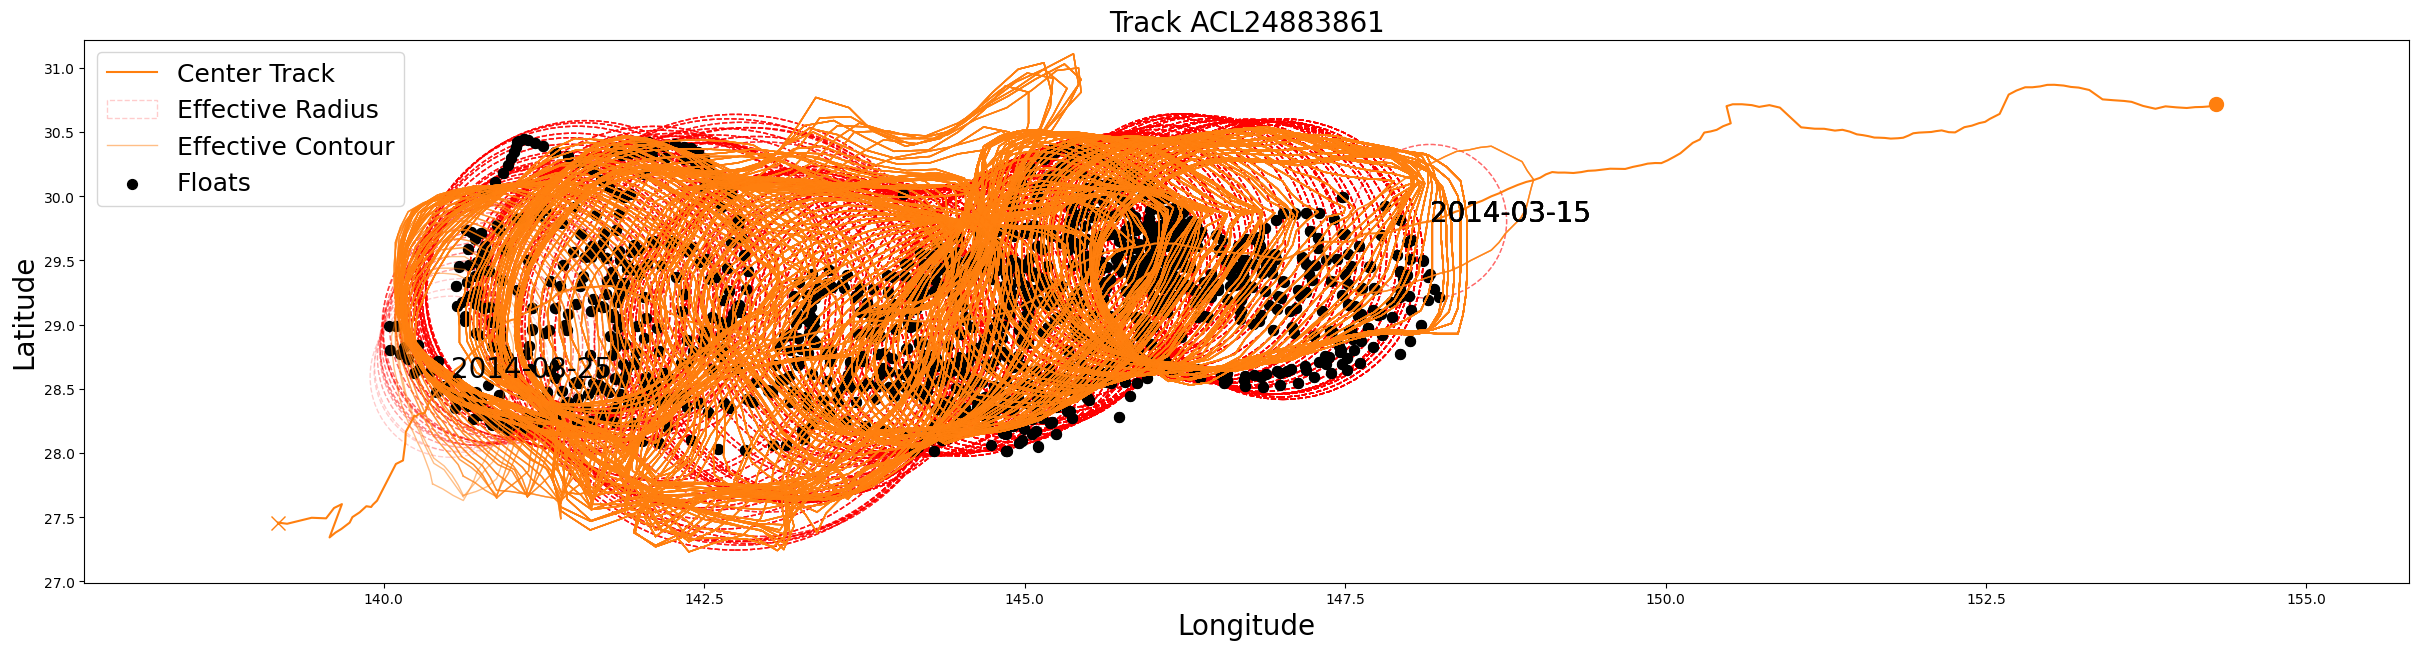

In [5]:
plot_track(acl, 24883861)

/tmp/ipykernel_262734/221441853.py:21: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


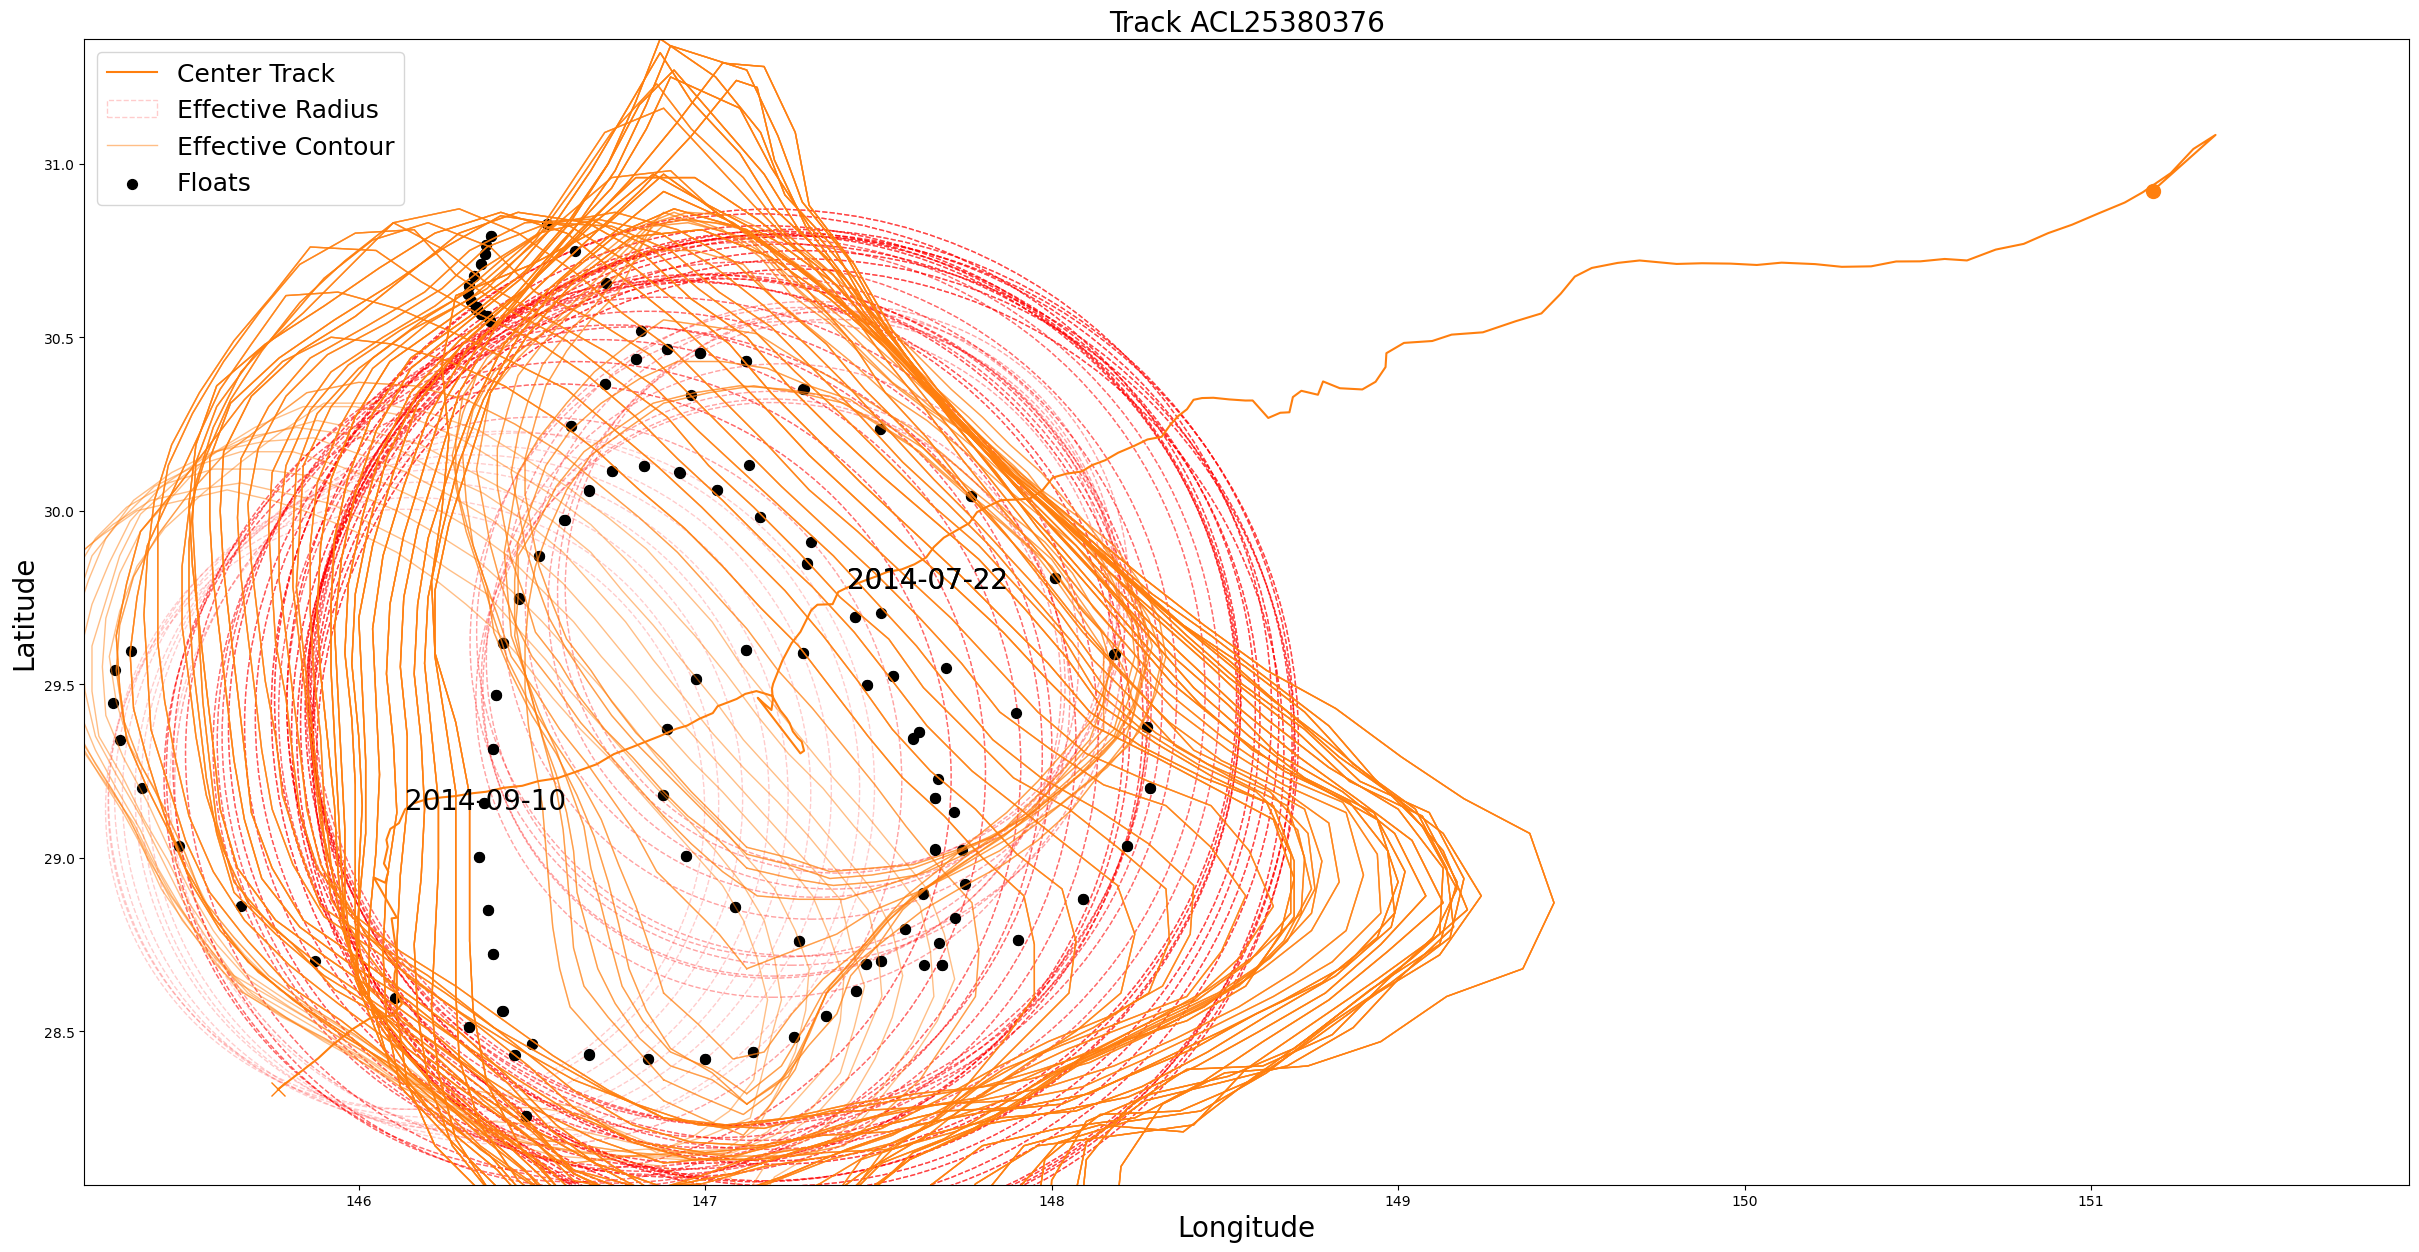

In [6]:
plot_track(acl, 25380376)

/tmp/ipykernel_262734/221441853.py:21: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


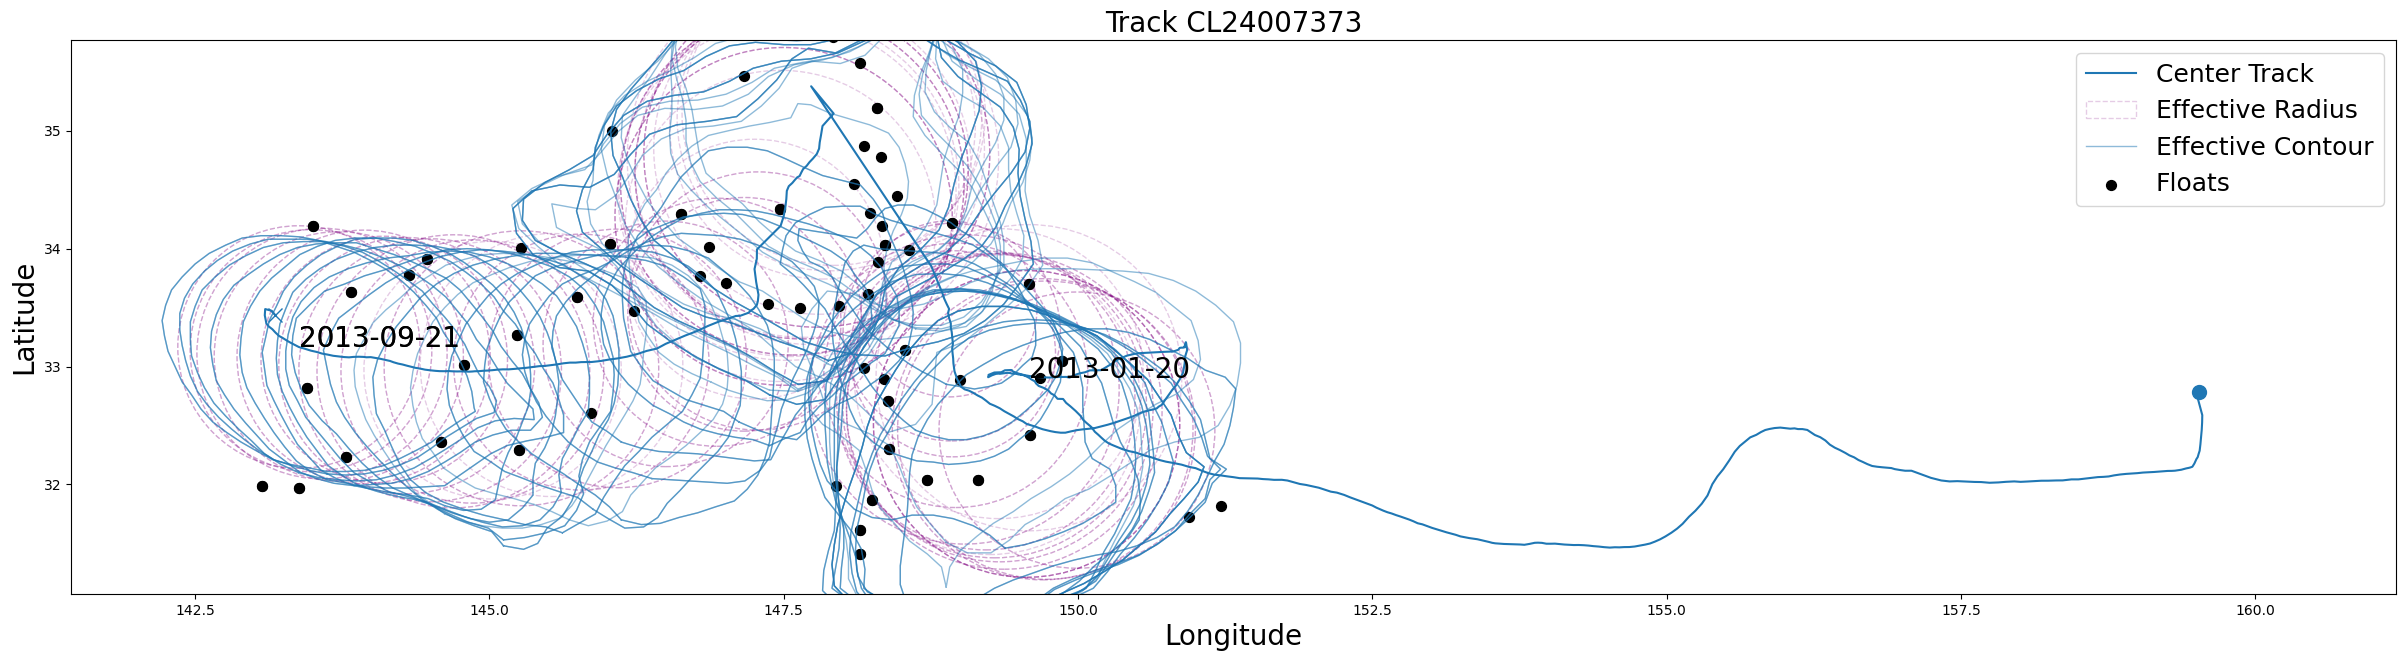

In [7]:
plot_track(cl, 24007373)

/tmp/ipykernel_262734/221441853.py:21: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


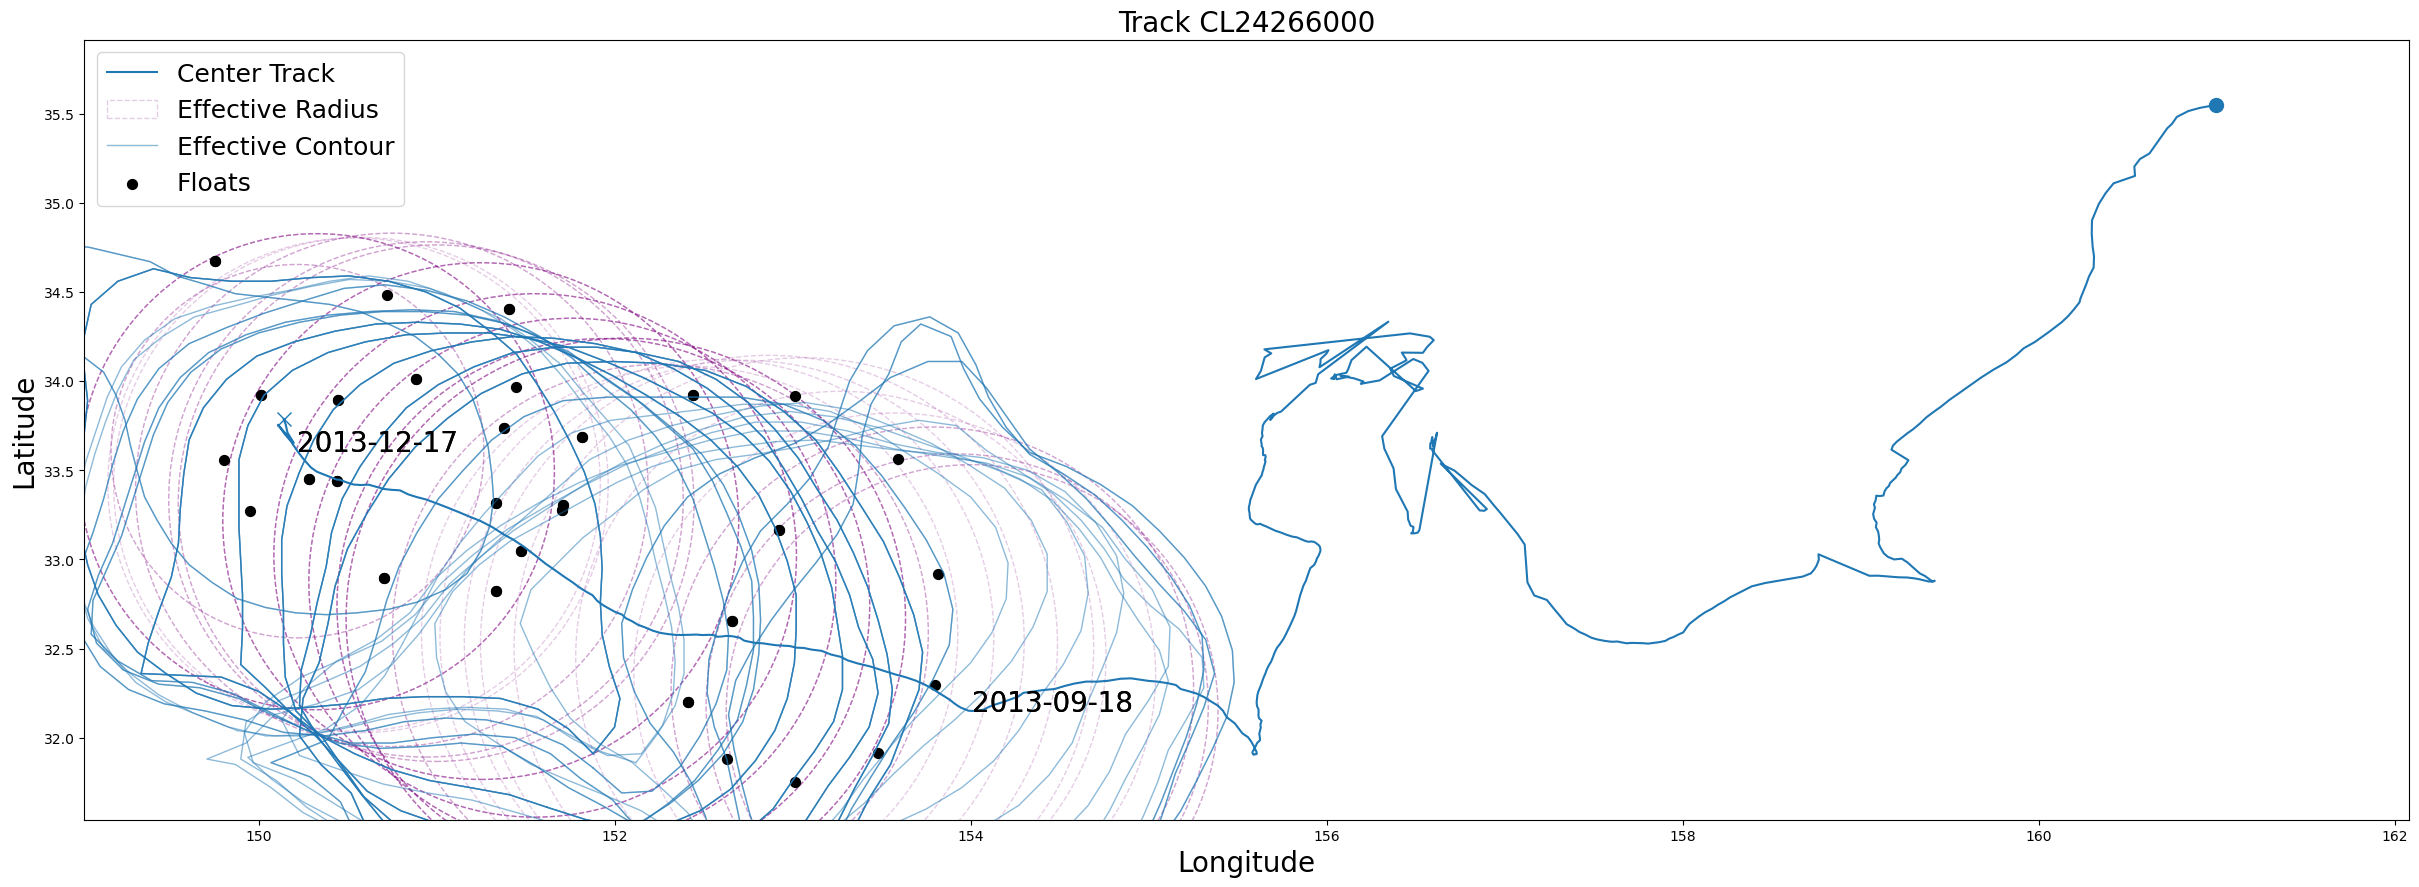

In [8]:
plot_track(cl, 24266000)

# 与原始数据对比
增大lonmin,lonmax latmin,latmax避免原始数据中一整条涡旋轨迹被切断

In [9]:
wanted_track=find_track(acl, 24883861)
num, time, center_lon, center_lat, max_lon, max_lat, contour_lon, contour_lat, radius = zip(*wanted_track)

t0= np.datetime64('1950-01-01')
dates = t0 + time
print(dates)

['2013-12-03' '2013-12-04' '2013-12-05' '2013-12-06' '2013-12-07'
 '2013-12-08' '2013-12-09' '2013-12-10' '2013-12-11' '2013-12-12'
 '2013-12-13' '2013-12-14' '2013-12-15' '2013-12-16' '2013-12-17'
 '2013-12-18' '2013-12-19' '2013-12-20' '2013-12-21' '2013-12-22'
 '2013-12-23' '2013-12-24' '2013-12-25' '2013-12-26' '2013-12-27'
 '2013-12-28' '2013-12-29' '2013-12-30' '2013-12-31' '2014-01-01'
 '2014-01-02' '2014-01-03' '2014-01-04' '2014-01-05' '2014-01-06'
 '2014-01-07' '2014-01-08' '2014-01-09' '2014-01-10' '2014-01-11'
 '2014-01-12' '2014-01-13' '2014-01-14' '2014-01-15' '2014-01-16'
 '2014-01-17' '2014-01-18' '2014-01-19' '2014-01-20' '2014-01-21'
 '2014-01-22' '2014-01-23' '2014-01-24' '2014-01-25' '2014-01-26'
 '2014-01-27' '2014-01-28' '2014-01-29' '2014-01-30' '2014-01-31'
 '2014-02-01' '2014-02-02' '2014-02-03' '2014-02-04' '2014-02-05'
 '2014-02-06' '2014-02-07' '2014-02-08' '2014-02-09' '2014-02-10'
 '2014-02-11' '2014-02-12' '2014-02-13' '2014-02-14' '2014-02-15'
 '2014-02-

In [37]:
ACL=Dataset('/Users/jjijack/Documents/Visual Studio Code/Python/EddyNet/META-Data-Converter/META3.1exp_DT_allsat_Anticyclonic_long_19930101_20200307.nc')

In [81]:
mask = ACL.variables['track'][:].data[24883861:24883861+1000]==ACL.variables['track'][:].data[24883861]
vt= ACL.variables['time'][:].data[24883861:24883861+1000][mask]
vlat= ACL.variables['latitude'][:].data[24883861:24883861+1000][mask]
vlon= ACL.variables['longitude'][:].data[24883861:24883861+1000][mask]

In [88]:
vt = t0 + vt
print(vt)

['2013-12-03' '2013-12-04' '2013-12-05' '2013-12-06' '2013-12-07'
 '2013-12-08' '2013-12-09' '2013-12-10' '2013-12-11' '2013-12-12'
 '2013-12-13' '2013-12-14' '2013-12-15' '2013-12-16' '2013-12-17'
 '2013-12-18' '2013-12-19' '2013-12-20' '2013-12-21' '2013-12-22'
 '2013-12-23' '2013-12-24' '2013-12-25' '2013-12-26' '2013-12-27'
 '2013-12-28' '2013-12-29' '2013-12-30' '2013-12-31' '2014-01-01'
 '2014-01-02' '2014-01-03' '2014-01-04' '2014-01-05' '2014-01-06'
 '2014-01-07' '2014-01-08' '2014-01-09' '2014-01-10' '2014-01-11'
 '2014-01-12' '2014-01-13' '2014-01-14' '2014-01-15' '2014-01-16'
 '2014-01-17' '2014-01-18' '2014-01-19' '2014-01-20' '2014-01-21'
 '2014-01-22' '2014-01-23' '2014-01-24' '2014-01-25' '2014-01-26'
 '2014-01-27' '2014-01-28' '2014-01-29' '2014-01-30' '2014-01-31'
 '2014-02-01' '2014-02-02' '2014-02-03' '2014-02-04' '2014-02-05'
 '2014-02-06' '2014-02-07' '2014-02-08' '2014-02-09' '2014-02-10'
 '2014-02-11' '2014-02-12' '2014-02-13' '2014-02-14' '2014-02-15'
 '2014-02-

In [101]:
print(vlat[vt==np.datetime64('2014-09-26')])
print(vlon[vt==np.datetime64('2014-09-26')])

[27.45815]
[139.17456]
